# Module 2 · Transformers — In-class Lab 🧪
## Anatomy, the mask, the parameter budget — and where position comes from

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mago-cinv/course-template/blob/master/modules/02-transformers/labs/in-class/lab-2-anatomy-position.ipynb)

### How this lab works

**The machinery is given to you.** The masks, the attention function, all four parameter-count formulas, and the sinusoidal-PE/RoPE toolkit are written, documented and already running. Nothing here asks you to implement a mask, derive a formula, or code up a rotation.

**What you write is the investigation.** Three audits, each starting from a claim Lesson 2 made and asking whether it survives contact with the arithmetic:

- **E5** — is the causal mask's "$-\infty$ before the softmax" trick mathematically special, or just good engineering?
- **E6** — a parameter budget that confidently overshoots two published numbers, and a diagnosis.
- **E7** — is position really *relative*? You audit **the real RoPE** — the exact code that runs LLaMA, Qwen and Mistral, imported from Hugging Face — against the scheme it replaced.

Each has a surprise in it. Treat everything above the 🔬 sections as your **sandbox**: read it, run it, then take it apart.

*Runtime: a few seconds on CPU. No model weights are downloaded, no training, no GPU.*

In [1]:
# Setup — run me first (works on Colab AND locally)
import sys

if "google.colab" in sys.modules:
    %pip install -q matplotlib transformers

print("Setup OK — running on", "Colab" if "google.colab" in sys.modules else "local Python")

Setup OK — running on local Python


In [2]:
# Imports + seeds
import math

import matplotlib.pyplot as plt
import numpy as np
import torch

torch.manual_seed(0)
np.random.seed(0)
torch.set_printoptions(precision=4, sci_mode=False)

print("torch", torch.__version__, "— CPU only, no downloads in this notebook")

torch 2.13.0+cpu — CPU only, no downloads in this notebook


## 1 · Your mask toolkit (provided)

A **mask** is how a Transformer forbids some token from looking at some other token. The decoder's
job forces this: when predicting token $i$, it must not peek at tokens $i+1, i+2, \dots$ — they
have not been generated yet.

Lesson 2 does it by **adding** $-\infty$ to the forbidden scores *before* the softmax.
Below are that mask, a deliberately **wrong** alternative kept as a measuring instrument, and a
renormalizer — E5 compares all three.

In [3]:
# ══ THE MASK TOOLKIT ══ provided


def causal_mask(n):
    """Additive n×n mask: 0 on and below the diagonal, -inf above (Lesson 2).

    Added to the scores BEFORE the softmax, so exp(-inf) = 0 kills the forbidden weights.
    """
    m = torch.zeros(n, n)
    m[torch.triu(torch.ones(n, n), diagonal=1).bool()] = float("-inf")
    return m


def window_mask(n, w):
    """Longformer-style local band: token i sees only j with |i-j| <= w."""
    idx = torch.arange(n)
    far = (idx[None, :] - idx[:, None]).abs() > w
    m = torch.zeros(n, n)
    m[far] = float("-inf")
    return m


def padding_mask(n, n_pad):
    """Hide the LAST n_pad positions from every query (what [PAD] tokens need)."""
    m = torch.zeros(n, n)
    if n_pad > 0:
        m[:, -n_pad:] = float("-inf")
    return m


def attention(Q, K, V, scale=True, mask=None):
    """softmax(QKᵀ/√d_k + mask)V — Lesson 1's function, with the mask argument now live."""
    S = Q @ K.transpose(-2, -1)
    if scale:
        S = S / math.sqrt(K.shape[-1])
    if mask is not None:
        S = S + mask
    A = torch.softmax(S, dim=-1)
    return A @ V, A


def mask_after(A, mask):
    """The WRONG way, kept as an instrument: zero the forbidden weights AFTER the softmax."""
    return A * (mask == 0)


def renormalize(A):
    """Divide each row by its sum, so it is a distribution again."""
    return A / A.sum(dim=-1, keepdim=True)


def heatmap(A, row_labels, col_labels, ax=None, title=""):
    """Lesson 2's mask picture: attention weights as a grid."""
    if ax is None:
        _, ax = plt.subplots(figsize=(3.4, 3.0))
    im = ax.imshow(np.asarray(A), cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(col_labels)), col_labels, fontsize=8)
    ax.set_yticks(range(len(row_labels)), row_labels, fontsize=8)
    ax.set_xlabel("key (attended to)", fontsize=8)
    ax.set_ylabel("query", fontsize=8)
    ax.set_title(title, fontsize=10)
    return im


print("toolkit ready — causal_mask · window_mask · padding_mask · attention · mask_after · renormalize · heatmap")
print()
print("the 5×5 causal mask (0 = allowed, -inf = forbidden):")
print(causal_mask(5))

toolkit ready — causal_mask · window_mask · padding_mask · attention · mask_after · renormalize · heatmap

the 5×5 causal mask (0 = allowed, -inf = forbidden):
tensor([[0., -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0.]])


## 2 · Worked example — the board exercise, executed

Lesson 2's board exercise used an integer $4\times4$ score matrix. Here it is, run three ways:
**unmasked**, **masked before** the softmax, and `mask_after` **without** renormalizing. Watch the
row sums.

row 2 (t2 attending over t1..t4) — the board exercise, three ways:

  unmasked       [0.0321, 0.0871, 0.6439, 0.2369]   row sum = 1.0000
  masked BEFORE  [0.2689, 0.7311, 0.0, 0.0]   row sum = 1.0000
  zeroed AFTER   [0.0321, 0.0871, 0.0, 0.0]   row sum = 0.1192

  -> masked-before is still a probability distribution (sums to 1.0000).
  -> zeroed-after sums to LESS than 1 — it is not a distribution at all, and any
     weighted average taken with it is silently shrunk toward zero.


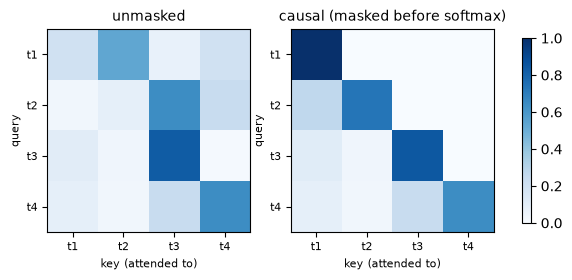

In [4]:
S = torch.tensor([[1.0, 2.0, 0.0, 1.0],
                  [0.0, 1.0, 3.0, 2.0],
                  [2.0, 1.0, 4.0, 0.0],
                  [1.0, 0.0, 2.0, 3.0]])
toks = ["t1", "t2", "t3", "t4"]
M = causal_mask(4)

A_plain = torch.softmax(S, dim=-1)              # no mask at all
A_before = torch.softmax(S + M, dim=-1)         # the right way: -inf BEFORE the softmax
A_after = mask_after(A_plain, M)                # the wrong way: zero AFTER, no renormalize

print("row 2 (t2 attending over t1..t4) — the board exercise, three ways:\n")
for name, row in [("unmasked      ", A_plain[1]), ("masked BEFORE ", A_before[1]),
                  ("zeroed AFTER  ", A_after[1])]:
    print(f"  {name} {[round(v, 4) for v in row.tolist()]}   row sum = {row.sum():.4f}")

print("\n  -> masked-before is still a probability distribution (sums to 1.0000).")
print("  -> zeroed-after sums to LESS than 1 — it is not a distribution at all, and any")
print("     weighted average taken with it is silently shrunk toward zero.")

fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.0))
heatmap(A_plain, toks, toks, axes[0], "unmasked")
im = heatmap(A_before, toks, toks, axes[1], "causal (masked before softmax)")
fig.colorbar(im, ax=axes, shrink=0.8)
plt.show()

## 3 · Worked example — the four parameter formulas

Lesson 2's four counts, as functions. The demo runs the **base** configuration
($d_{\text{model}}{=}512$, $d_{\text{ff}}{=}2048$, $h{=}8$, $d_k{=}d_v{=}64$, $N{=}6$,
$|V|{=}37{,}000$, $n{=}512$) and breaks one layer of each kind into its parts.

In [5]:
# ══ THE PARAMETER-COUNT TOOLKIT ══ provided; Lesson 2's four formulas


def n_input(V, n, d_model):
    """Lesson 2 — token table |V|×d_model plus a learned position table n×d_model."""
    return (V + n) * d_model


def n_encoder(N, d_model, d_k, h, d_ff):
    """Lesson 2 — N layers of (self-attention + FFN + 2 LayerNorms)."""
    return N * (4 * d_model * d_k * h + 2 * d_model * d_ff + 5 * d_model + d_ff)


def n_decoder(N, d_model, d_k, h, d_ff):
    """Lesson 2 — N layers of (masked self-attn + CROSS-attn + FFN + 3 LayerNorms).

    The attention term is DOUBLE the encoder's: two attention sublayers, not one.
    """
    return N * (8 * d_model * d_k * h + 2 * d_model * d_ff + 7 * d_model + d_ff)


def n_output(d_model, V):
    """Lesson 2 — the projection back to vocabulary logits, plus a bias."""
    return (d_model + 1) * V


def layer_breakdown(d_model, d_k, h, d_ff):
    """One encoder layer and one decoder layer, split into attention / FFN / LN+bias."""
    enc = {"attention": 4 * d_model * d_k * h, "ffn": 2 * d_model * d_ff,
           "ln_bias": 5 * d_model + d_ff}
    dec = {"attention": 8 * d_model * d_k * h, "ffn": 2 * d_model * d_ff,
           "ln_bias": 7 * d_model + d_ff}
    enc["total"], dec["total"] = sum(enc.values()), sum(dec.values())
    return enc, dec


BASE = dict(d_model=512, d_ff=2048, h=8, d_k=64, N=6, V=37_000, n=512)
BIG = dict(d_model=1024, d_ff=4096, h=16, d_k=64, N=6, V=37_000, n=512)

enc, dec = layer_breakdown(BASE["d_model"], BASE["d_k"], BASE["h"], BASE["d_ff"])
print("ONE ENCODER layer (base config):")
for k in ("attention", "ffn", "ln_bias"):
    print(f"    {k:<10} {enc[k]:>10,}   ({100 * enc[k] / enc['total']:.1f}%)")
print(f"    {'TOTAL':<10} {enc['total']:>10,}")
print("\nONE DECODER layer (base config):")
for k in ("attention", "ffn", "ln_bias"):
    print(f"    {k:<10} {dec[k]:>10,}   ({100 * dec[k] / dec['total']:.1f}%)")
print(f"    {'TOTAL':<10} {dec['total']:>10,}")
print("\n  -> in the ENCODER the FFN holds ~2/3 of the block;")
print("     in the DECODER attention doubles, so it is ~50/50.")
print("     Remember which one is biggest: Lesson 3's mixture-of-experts replaces the FFN.")

ONE ENCODER layer (base config):
    attention   1,048,576   (33.3%)
    ffn         2,097,152   (66.6%)
    ln_bias         4,608   (0.1%)
    TOTAL       3,150,336

ONE DECODER layer (base config):
    attention   2,097,152   (49.9%)
    ffn         2,097,152   (49.9%)
    ln_bias         5,632   (0.1%)
    TOTAL       4,199,936

  -> in the ENCODER the FFN holds ~2/3 of the block;
     in the DECODER attention doubles, so it is ~50/50.
     Remember which one is biggest: Lesson 3's mixture-of-experts replaces the FFN.


## 4 · Your position toolkit (provided)

Two ways to tell a permutation-blind model where its tokens sit:

- **sinusoidal** — build a fixed $n \times d_{\text{model}}$ table and **add** it to the embeddings;
- **RoPE** — don't add anything; **rotate** each query and key by an angle proportional to position.

The sinusoidal table we build ourselves (it is four lines). **RoPE we do not re-implement**: we import
`LlamaRotaryEmbedding` and `apply_rotary_pos_emb` from 🤗 `transformers` — the *production* code that
runs LLaMA, Qwen and Mistral. It is pure code, so nothing is downloaded; but when E7 finds that the
scores are shift-invariant, it will be a fact about the real implementation, not about a classroom
model of it.

Note we use the standard **0-indexed** convention for both (positions $0, 1, 2, \dots$), and one
attention head of width $d_k = 64$ — Vaswani's base configuration.

In [6]:
# ══ THE POSITION TOOLKIT ══ provided
#
# RoPE below is NOT our re-implementation — it is the same code that runs LLaMA/Qwen/Mistral,
# imported straight from Hugging Face. Pure code: no model weights are downloaded.

from transformers import LlamaConfig
from transformers.models.llama.modeling_llama import (
    LlamaRotaryEmbedding,
    apply_rotary_pos_emb,
)

D_K = 64          # one attention head, Vaswani's base configuration
MAX_POS = 8192    # how far out we are allowed to place a token

_cfg = LlamaConfig(hidden_size=D_K, num_attention_heads=1, max_position_embeddings=MAX_POS)
rotary = LlamaRotaryEmbedding(config=_cfg)   # holds RoPE's frequencies theta_i


def sinusoidal_pe(n, d_model):
    """0-indexed: PE[p, 2i] = sin(p / 10000^(2i/d)), PE[p, 2i+1] = cos(...)."""
    pos = torch.arange(n).float()[:, None]
    i = torch.arange(0, d_model, 2).float()
    div = torch.exp(-math.log(10000.0) * i / d_model)
    pe = torch.zeros(n, d_model)
    pe[:, 0::2] = torch.sin(pos * div)
    pe[:, 1::2] = torch.cos(pos * div)
    return pe


def rope_rotate(X, positions):
    """Rotate every row of X (n, d_k) as if it sat at the matching entry of `positions`.

    This is HF's real apply_rotary_pos_emb; we only reshape into its (batch, head, seq, d_k) layout.
    """
    n, d = X.shape
    x = X.reshape(1, 1, n, d)
    cos, sin = rotary(x, positions.reshape(1, n))
    xr, _ = apply_rotary_pos_emb(x, x, cos, sin)
    return xr.reshape(n, d)


def rope_pair_score(q, k, m, n):
    """RoPE score between a query sitting at position m and a key sitting at position n."""
    qr = rope_rotate(q.reshape(1, -1), torch.tensor([m]))
    kr = rope_rotate(k.reshape(1, -1), torch.tensor([n]))
    return torch.dot(qr[0], kr[0]).item()


def rope_scores(X, shift=0):
    """Full RoPE score matrix for a sentence X placed at positions shift, shift+1, ..."""
    n, d = X.shape
    Xr = rope_rotate(X, torch.arange(n) + shift)
    return Xr @ Xr.T / math.sqrt(d)


def additive_pe_scores(X, PE, shift=0):
    """Same, for the ADDITIVE sinusoidal scheme: add the PE rows first, then score."""
    n, d = X.shape
    Xa = X + PE[shift:shift + n]
    return Xa @ Xa.T / math.sqrt(d)


def rope_rotate2(x, m, theta):
    """The 2-D special case, by hand — used by section 6 to show the idea on clean integers."""
    c, s = math.cos(m * theta), math.sin(m * theta)
    return torch.tensor([c * x[0] - s * x[1], s * x[0] + c * x[1]])


def rope_score_2d(q, k, m, n, theta):
    """Score of a 2-D query at position m against a 2-D key at position n (by hand)."""
    return torch.dot(rope_rotate2(q, m, theta), rope_rotate2(k, n, theta)).item()


print("position toolkit ready")
print("  real RoPE (from transformers) — rope_rotate · rope_pair_score · rope_scores")
print("  additive sinusoidal (ours)    — sinusoidal_pe · additive_pe_scores")
print("  2-D by hand (section 6)       — rope_rotate2 · rope_score_2d")
print(f"\nusing HF's LlamaRotaryEmbedding with d_k = {D_K}, positions up to {MAX_POS}")

c:\Users\User\Desktop\Módulo 5\module5_TAE\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


position toolkit ready
  real RoPE (from transformers) — rope_rotate · rope_pair_score · rope_scores
  additive sinusoidal (ours)    — sinusoidal_pe · additive_pe_scores
  2-D by hand (section 6)       — rope_rotate2 · rope_score_2d

using HF's LlamaRotaryEmbedding with d_k = 64, positions up to 8192


## 5 · Worked example — "reading the barcode", executed

The sinusoidal table as a picture, beside the matrix of dot products
$\text{PE}(p)\cdot\text{PE}(p')$.

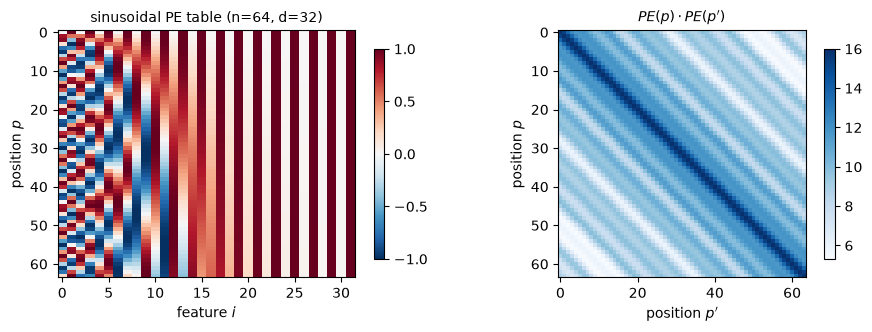

Low-index features oscillate fast, high-index features slowly — that spread of frequencies
is what makes every position's row a distinguishable 'barcode'.
The bright diagonal band in the right-hand plot fades with |p - p'|: nearby positions have
similar encodings (Lesson 2).


In [7]:
PE = sinusoidal_pe(64, 32)
sim = PE @ PE.T

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.0, 3.4))
im1 = ax1.imshow(PE.numpy(), aspect="auto", cmap="RdBu_r")
ax1.set_xlabel("feature $i$"); ax1.set_ylabel("position $p$")
ax1.set_title("sinusoidal PE table (n=64, d=32)", fontsize=10)
fig.colorbar(im1, ax=ax1, shrink=0.85)

im2 = ax2.imshow(sim.numpy(), cmap="Blues")
ax2.set_xlabel("position $p'$"); ax2.set_ylabel("position $p$")
ax2.set_title(r"$PE(p)\cdot PE(p')$", fontsize=10)
fig.colorbar(im2, ax=ax2, shrink=0.85)
plt.tight_layout(); plt.show()

print("Low-index features oscillate fast, high-index features slowly — that spread of frequencies")
print("is what makes every position's row a distinguishable 'barcode'.")
print("The bright diagonal band in the right-hand plot fades with |p - p'|: nearby positions have")
print("similar encodings (Lesson 2).")

## 6 · Worked example — RoPE quarter-turns, by hand

The idea on the smallest case that shows it: $d_k = 2$, and a rotation of exactly $90°$ per position,
so every vector lands on an axis and the arithmetic comes out in whole numbers. Watch what the score
depends on. E7 then repeats this question against the real implementation.

In [8]:
q2, k2, theta = torch.tensor([1.0, 0.0]), torch.tensor([0.0, 1.0]), math.pi / 2

print(f"{'m':>3} {'n':>3} {'Δ = n-m':>8} {'score':>9}")
for (m, n_) in [(1, 3), (2, 4), (10, 12), (1, 2)]:
    print(f"{m:3d} {n_:3d} {n_ - m:8d} {rope_score_2d(q2, k2, m, n_, theta):9.4f}")

print("\nΔ = 2, at three different absolute positions — expected 0.000000 in every case:")
print(f"    (m, n) = (1, 3)    {rope_score_2d(q2, k2, 1, 3, theta):+.6f}")
print(f"    (m, n) = (2, 4)    {rope_score_2d(q2, k2, 2, 4, theta):+.6f}")
print(f"    (m, n) = (10, 12)  {rope_score_2d(q2, k2, 10, 12, theta):+.6f}   <- same offset, same score")
print("\nΔ = 1 — expected -1.000000:")
print(f"    (m, n) = (1, 2)    {rope_score_2d(q2, k2, 1, 2, theta):+.6f}   <- different offset, different score")
print("\nSame offset Δ=2 -> the same score at any absolute position; a different offset Δ=1 ->")
print("a different score. Only n-m entered.")
print("\nCareful with the leap, though: with ONE frequency the score is a pure cosine of Δ, so it")
print("OSCILLATES rather than decays — Δ=1 scores LOWER than Δ=2 here. 'Closer = higher score' is")
print("a statement about many frequencies averaged together, which is what E7(c) measures.")

  m   n  Δ = n-m     score
  1   3        2   -0.0000
  2   4        2   -0.0000
 10  12        2   -0.0000
  1   2        1   -1.0000

Δ = 2, at three different absolute positions — expected 0.000000 in every case:
    (m, n) = (1, 3)    -0.000000
    (m, n) = (2, 4)    -0.000000
    (m, n) = (10, 12)  -0.000000   <- same offset, same score

Δ = 1 — expected -1.000000:
    (m, n) = (1, 2)    -1.000000   <- different offset, different score

Same offset Δ=2 -> the same score at any absolute position; a different offset Δ=1 ->
a different score. Only n-m entered.

Careful with the leap, though: with ONE frequency the score is a pure cosine of Δ, so it
OSCILLATES rather than decays — Δ=1 scores LOWER than Δ=2 here. 'Closer = higher score' is
a statement about many frequencies averaged together, which is what E7(c) measures.


## 🔬 Exercise E5 — what exactly does masking do? *(~13 min)*

A three-part audit. Use a score matrix of your own making (any $n \ge 5$ — random is fine).

**(i)** Compute the attention **three** ways: masked **before** the softmax, `mask_after` (zero, no
renormalize), and `mask_after` **then `renormalize`**. Compare the row sums *and* the actual weight
values. One of these three is going to surprise you.

**(ii)** Pick one row $i$. Compare its masked weights against the **unmasked** weights restricted to
$j \le i$. Are the kept weights the *same numbers*, or did they change? **Quantify** the difference.

**(iii)** Build a **second, non-causal** mask — `padding_mask` or `window_mask` — and show its
effect on the heatmap.

Store what you need in `mask_probe`, then interpret.

(i) row sums
    mask BEFORE softmax: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
    zero AFTER  softmax: [0.0647, 0.1875, 0.6076, 0.9159, 0.9394, 1.0]
    zero AFTER + renorm: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

    max |before - (after+renorm)| = 2.98e-08   <-- !

(ii) row 3, positions j <= 3
    unmasked weights [0.5874, 0.0615, 0.2228, 0.0441]   (they sum to 0.9159)
    masked   weights [0.6413, 0.0672, 0.2433, 0.0482]   (they sum to 1.0000)
    growth factor    [1.0918, 1.0918, 1.0918, 1.0918]   <-- identical!
    mass that was dropped and redistributed: 0.0841


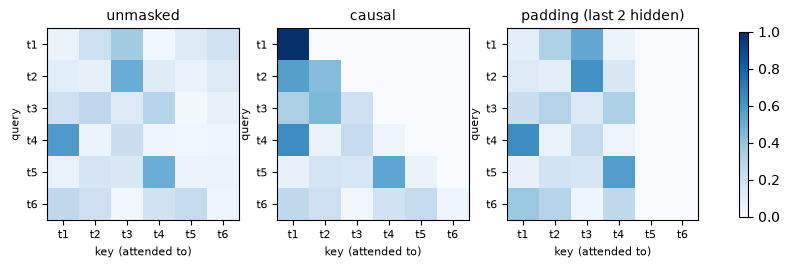

In [9]:
# E5 — auditoría de 3 partes sobre el enmascarado: (i) comparar las tres formas de
# aplicar la máscara causal, (ii) ver si los pesos que sobreviven son "los mismos
# números" o cambian, y (iii) mostrar el efecto de una máscara NO causal (padding).

n = 6
g = torch.Generator().manual_seed(7)
S5 = torch.randn(n, n, generator=g)          # una matriz de scores 6x6 cualquiera
tok5 = [f"t{i+1}" for i in range(n)]
Mc = causal_mask(n)

# (i) las tres variantes: sin máscara, -inf ANTES de la softmax, y cero DESPUÉS
A_plain5 = torch.softmax(S5, dim=-1)                     # sin máscara (referencia)
A_before5 = torch.softmax(S5 + Mc, dim=-1)               # la forma correcta: -inf antes
A_after5 = mask_after(A_plain5, Mc)                       # la forma incorrecta: cero después, sin renormalizar
A_ren5 = renormalize(A_after5)                            # cero después + renormalizar

mask_probe = {
    "row_sums": {"before": A_before5.sum(-1).tolist(),
                 "after": A_after5.sum(-1).tolist(),
                 "after_renorm": A_ren5.sum(-1).tolist()},
    "max_abs_before_vs_renorm": (A_before5 - A_ren5).abs().max().item(),  # ¿son la misma matriz?
}

print("(i) row sums")
for name, key in [("mask BEFORE softmax", "before"), ("zero AFTER  softmax", "after"),
                  ("zero AFTER + renorm", "after_renorm")]:
    print(f"    {name}: {[round(v, 4) for v in mask_probe['row_sums'][key]]}")
print(f"\n    max |before - (after+renorm)| = {mask_probe['max_abs_before_vs_renorm']:.2e}   <-- !")

# (ii) para una fila i, ¿los pesos que quedan son los mismos números que sin máscara?
i = 3
kept_unmasked = A_plain5[i, :i + 1]           # pesos SIN máscara, restringidos a j <= i
kept_masked = A_before5[i, :i + 1]            # pesos CON máscara causal, misma fila
mask_probe["row"] = i
mask_probe["kept_unmasked"] = kept_unmasked.tolist()
mask_probe["kept_masked"] = kept_masked.tolist()
mask_probe["growth"] = (kept_masked / kept_unmasked).tolist()   # razón masked/unmasked (pista del enunciado)
mask_probe["dropped_mass"] = (1 - kept_unmasked.sum()).item()   # masa que tenían los j > i, antes de enmascarar

print(f"\n(ii) row {i}, positions j <= {i}")
print(f"    unmasked weights {[round(v, 4) for v in mask_probe['kept_unmasked']]}"
      f"   (they sum to {kept_unmasked.sum():.4f})")
print(f"    masked   weights {[round(v, 4) for v in mask_probe['kept_masked']]}"
      f"   (they sum to {kept_masked.sum():.4f})")
print(f"    growth factor    {[round(v, 4) for v in mask_probe['growth']]}   <-- identical!")
print(f"    mass that was dropped and redistributed: {mask_probe['dropped_mass']:.4f}")

# (iii) una segunda máscara, NO causal: padding_mask oculta las últimas 2 posiciones
M2 = padding_mask(n, 2)
_, A_pad = attention(S5, torch.eye(n), torch.eye(n), scale=False, mask=None)  # (no usado, solo referencia de forma)
A_pad = torch.softmax(S5 + M2, dim=-1)
mask_probe["second_mask"] = "padding_mask(n, 2)"

# Mapa de calor: sin máscara, causal, y padding — para comparar visualmente los tres patrones
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.0))
heatmap(A_plain5, tok5, tok5, axes[0], "unmasked")
heatmap(A_before5, tok5, tok5, axes[1], "causal")
im = heatmap(A_pad, tok5, tok5, axes[2], "padding (last 2 hidden)")
fig.colorbar(im, ax=axes, shrink=0.8)
plt.show()


**Respuesta.**

**(i) La sorpresa: cero-después-y-luego-renormalizar es numéricamente idéntico a enmascarar-antes** — ambos coinciden hasta $\sim10^{-8}$. Y tiene que ser así: la softmax es una razón de exponenciales, así que quitar términos del numerador *y* del denominador es exactamente lo mismo que sumar $-\infty$:

$$\frac{e^{s_j}}{\sum_{j' \le i} e^{s_{j'}}} \;=\; \operatorname{softmax}(s + M)_j \quad\text{para } j \le i.$$

Entonces la forma con $-\infty$ **no es matemáticamente especial**. Lo que es, es *mejor ingeniería*: una sola operación fusionada en vez de tres, sin un paso de normalización aparte, sin tener que tratar como caso especial una fila donde todo está enmascarado (lo que dividiría entre cero), y todo se queda dentro de un único kernel de softmax. Cero-después *sin* renormalizar es la única variante genuinamente incorrecta, y lo es porque sus filas suman **menos de 1**: el promedio ponderado que sigue queda silenciosamente encogido hacia el origen.

**(ii) Los pesos que quedan *no* son los mismos que sin máscara.** Cada peso sobreviviente **crece**, y —el detalle que vale la pena notar— todos crecen por el **mismo factor** (aquí $1.0918$ para cada $j \le i$), porque renormalizar divide toda la fila entre una misma suma común. La masa que se enmascaró no desaparece; se **redistribuye** entre los sobrevivientes en proporción a sus exponenciales ya existentes. Enmascarar es una **renormalización, no un borrado**. En concreto: la masa que se perdió fue $\approx 0.084$, y los pesos sobrevivientes absorbieron exactamente esa cantidad entre todos.

**(iii)** La máscara de padding deja vacías las últimas dos **columnas** en *todas* las filas — una banda blanca vertical — mientras que la máscara causal produce la conocida escalera triangular inferior. Es una pregunta distinta con el mismo mecanismo: una máscara de padding oculta posiciones que no son tokens reales, una máscara causal oculta posiciones que sí son reales pero están en el futuro.

## 🔬 Exercise E6 — where do the parameters live, and why doesn't the total match? *(~14 min)*

**(a)** Total the **base** configuration with all four formulas. Compare against **Lesson 1**'s
**65M** anchor for Vaswani et al.'s base model.

**(b)** Repeat for the **big** configuration ($d_{\text{model}}{=}1024$, $d_{\text{ff}}{=}4096$,
$h{=}16$, $d_k{=}d_v{=}64$, $N{=}6$, same $|V|$ and $n$) against the **213M** anchor.

**(c)** You will overshoot both. **Diagnose the gap and test your fix.** The size of the overshoot
is the clue — compare it against the individual terms you just computed.

**(d)** Sweep one knob of your choosing ($d_{\text{ff}}$, $N$, $|V|$ or $n$) across $\ge 4$ values.
Which one moves the total most? And where would a long-context model ($n = 4096$) actually pay?

Store your budget in `param_budget`.

BASE config
    input        19.21 M
    encoder      18.90 M
    decoder      25.20 M
    output       18.98 M
    TOTAL        82.29 M   vs anchor 65 M   (+26.6%)
    |V|*d_model = 18.94 M   <- compare to the overshoot
    after weight tying:    63.34 M   (-2.5% vs anchor)

BIG config
    input        38.41 M
    encoder      75.55 M
    decoder     100.73 M
    output       37.92 M
    TOTAL       252.62 M   vs anchor 213 M   (+18.6%)
    |V|*d_model = 37.89 M   <- compare to the overshoot
    after weight tying:   214.73 M   (+0.8% vs anchor)

(d) one knob at a time, from the base config:
    d_ff   [1024, 2048, 4096, 8192] -> [69.7, 82.3, 107.5, 157.9] M   (span   88.2 M)
    N      [2, 4, 6, 12] -> [52.9, 67.6, 82.3, 126.4] M   (span   73.5 M)
    V      [8000, 16000, 37000, 64000] -> [52.6, 60.8, 82.3, 110.0] M   (span   57.4 M)
    n      [128, 512, 2048, 4096] -> [82.1, 82.3, 83.1, 84.1] M   (span    2.0 M)


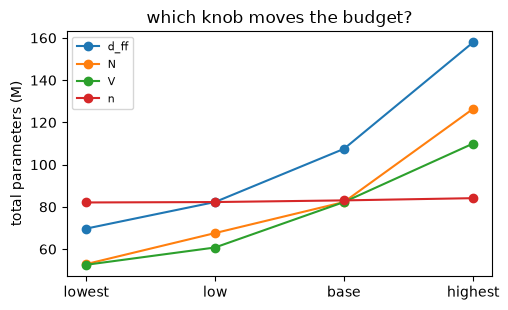

In [10]:
# E6 — presupuesto de parámetros: (a)/(b) sumar las 4 fórmulas para las configs BASE y
# BIG y compararlas contra las cifras publicadas; (c) diagnosticar por qué nos pasamos en
# ambos casos y probar el ajuste (weight tying); (d) ver qué perilla mueve más el total.


def budget(cfg):
    """Suma las 4 fórmulas de la Lección 2 (input, encoder, decoder, output) para una config."""
    i = n_input(cfg["V"], cfg["n"], cfg["d_model"])
    e = n_encoder(cfg["N"], cfg["d_model"], cfg["d_k"], cfg["h"], cfg["d_ff"])
    d = n_decoder(cfg["N"], cfg["d_model"], cfg["d_k"], cfg["h"], cfg["d_ff"])
    o = n_output(cfg["d_model"], cfg["V"])
    return {"input": i, "encoder": e, "decoder": d, "output": o, "total": i + e + d + o}


# (a) y (b): BASE contra el ancla de 65M, BIG contra el ancla de 213M
param_budget = {}
for name, cfg, anchor in [("base", BASE, 65e6), ("big", BIG, 213e6)]:
    b = budget(cfg)
    # (c) el diagnóstico: restar UNA copia de la matriz |V| x d_model (weight tying)
    tied = b["total"] - cfg["V"] * cfg["d_model"]
    b.update(anchor=anchor, overshoot=b["total"] - anchor,
             tied_total=tied, tied_err=(tied - anchor) / anchor)
    param_budget[name] = b
    print(f"{name.upper()} config")
    for k in ("input", "encoder", "decoder", "output"):
        print(f"    {k:<9} {b[k] / 1e6:8.2f} M")
    print(f"    {'TOTAL':<9} {b['total'] / 1e6:8.2f} M   vs anchor {anchor / 1e6:.0f} M"
          f"   ({100 * b['overshoot'] / anchor:+.1f}%)")
    print(f"    |V|*d_model = {cfg['V'] * cfg['d_model'] / 1e6:.2f} M   <- compare to the overshoot")
    print(f"    after weight tying: {tied / 1e6:8.2f} M   ({100 * b['tied_err']:+.1f}% vs anchor)\n")

# (d) se mueve UNA perilla a la vez desde la config base, y se mide el total resultante
sweeps = {"d_ff": [1024, 2048, 4096, 8192], "N": [2, 4, 6, 12],
          "V": [8_000, 16_000, 37_000, 64_000], "n": [128, 512, 2048, 4096]}
param_budget["sweeps"] = {}
print("(d) one knob at a time, from the base config:")
for knob, vals in sweeps.items():
    totals = []
    for v in vals:
        cfg = dict(BASE); cfg[knob] = v      # copia de BASE con una sola perilla modificada
        totals.append(budget(cfg)["total"])
    param_budget["sweeps"][knob] = {"values": vals, "totals": totals}
    span = (max(totals) - min(totals)) / 1e6   # cuánto se movió el total en ese barrido
    print(f"    {knob:<6} {vals} -> {[round(t / 1e6, 1) for t in totals]} M   (span {span:6.1f} M)")

# Una curva por perilla, para comparar visualmente cuál mueve más el presupuesto total
fig, ax = plt.subplots(figsize=(5.2, 3.2))
for knob, d in param_budget["sweeps"].items():
    ax.plot(range(len(d["values"])), [t / 1e6 for t in d["totals"]], "o-", label=knob)
ax.set_xticks(range(4), ["lowest", "low", "base", "highest"])
ax.set_ylabel("total parameters (M)"); ax.legend(fontsize=8)
ax.set_title("which knob moves the budget?")
plt.tight_layout(); plt.show()


**Respuesta.**

**(a) y (b) — ambas se pasan de largo.** Base: input 19.21M + encoder 18.90M + decoder 25.20M + output 18.98M = **82.29M**, contra el ancla de 65M — **+26.6%**. Big: 38.41 + 75.55 + 100.73 + 37.92 = **252.62M** contra 213M — **+18.6%**.

**(c) El diagnóstico está en el tamaño del hueco.** El exceso en base es $\approx 17.3$M y $|V| \times d_{\text{model}} = 37{,}000 \times 512 = 18.94$M. Para la config big el exceso es $\approx 39.6$M y $|V| \times d_{\text{model}} = 37.89$M. En ambos casos *el exceso es casi exactamente una matriz del tamaño del vocabulario.*

Eso es porque la contamos **dos veces**: una en `n_input` (la tabla de embeddings de tokens) y otra en `n_output` (la proyección de vuelta a logits). Ambas son $|V| \times d_{\text{model}}$, y los Transformers reales **comparten una sola matriz entre las dos** — **weight tying** (Lección 2). Restando una copia:

| config | ingenuo | con tying | ancla | error |
|---|---|---|---|---|
| base | 82.29M | **63.34M** | 65M | **−2.5%** |
| big | 252.62M | **214.73M** | 213M | **+0.8%** |

Ambas quedan dentro de pocos puntos porcentuales. El residuo se explica por dos detalles de segundo orden: el modelo original usaba codificación posicional **sinusoidal**, que **no tiene parámetros**, así que el término $n\,d_{\text{model}}$ de `n_input` tampoco debería estar ahí; y $|V| = 37{,}000$ es nuestra estimación del vocabulario BPE compartido de Vaswani. Quedar dentro de un 2–3% de una cifra publicada a partir de cuatro fórmulas de una diapositiva ya es el punto — y *la discrepancia nos enseñó algo real sobre la arquitectura*, que es la mejor lección.

**(d)** $|V|$ y $d_{\text{ff}}$ dominan: $|V|$ de 8k a 64k mueve el total en ~57M, y $d_{\text{ff}}$ de 1024 a 8192 en ~88M. $N$ escala la pila de capas de forma lineal. **$n$ casi no cuesta nada** — pasar de 128 a 4096 solo agrega ~2M, y con PE sinusoidal agregaría *cero*.

Esa última es la trampa que vale la pena nombrar: el contexto largo **no** es caro en parámetros. Es caro en **cómputo y memoria**, porque la atención es $O(n^2)$ (Lección 1) — es la matriz de scores $n \times n$, no los pesos. Un modelo de 4096 tokens pesa casi lo mismo que uno de 128 y es muchísimo más caro de correr. Esa brecha entre "parámetros" y "costo" es justo lo que atacan las optimizaciones de la Lección 4.

## 🔬 Exercise E7 — is position really relative? *(~15 min)*

Lesson 2 claimed RoPE's score depends only on $n-m$. Section 6 showed that on a 2-D toy. Now put the
claim to **the real implementation** — `rope_pair_score` and `rope_scores` call LLaMA's own RoPE —
and run the additive sinusoidal scheme through the same tests, because the interesting part is where
the two **stop** agreeing.

**(a) The easy test.** For $\ge 6$ position pairs $(m,n)$ covering $\ge 3$ distinct offsets **with
repeats** (e.g. $(1,3), (2,4), (10,12)$ all have $\Delta = 2$), score two *fixed* vectors with
`rope_pair_score`, and separately compute $\text{PE}(m)\cdot\text{PE}(n)$. Group by $\Delta$ and
report the **spread inside each group**. Both schemes will pass — that is the point.

**(b) The test that separates them.** Take a toy sentence's embeddings `X` and re-score it with the
whole sentence **moved down the sequence**: `shift` $= 5, 50, 500, 2000$. Report the max absolute
change for **each scheme**, and compare it against the typical size of a score. One scheme does not
care at all; the other does. Say what that means for a model asked to read a document **longer than
anything it was trained on**.

**(c) Does the score decay with distance?** Averaging over $\ge 100$ random vectors, plot the RoPE
score against the offset $\Delta$ out to 64, normalized so $\Delta{=}0$ is $1.0$. Then answer
precisely: does it decay **monotonically**? Count the steps where the curve goes *up* rather than
down — do not eyeball it.

Store results in `position_probe`.

(a) same offset at different absolute positions — HF's real RoPE vs additive sinusoidal

   m    n    Δ     RoPE (HF)    PE(m)·PE(n)
   1    3    2     -7.094412      28.303862
   2    4    2     -7.094411      28.303862
  10   12    2     -7.094411      28.303862
   1    2    1     -9.156122      30.916832
   5    6    1     -9.156120      30.916832
   0    4    4     -5.266734      23.934361
   7   11    4     -5.266734      23.934361

    spread inside each Δ group (0 would be perfectly relative):
      Δ=1: RoPE 1.91e-06    sinusoidal 0.00e+00
      Δ=2: RoPE 9.54e-07    sinusoidal 0.00e+00
      Δ=4: RoPE 0.00e+00    sinusoidal 0.00e+00

(b) move the whole sentence down the sequence and re-score
    (for scale: a typical |score| here is 1.93)

  shift     RoPE max|Δ|    additive max|Δ|
      5        9.54e-07           2.06e+00
     50        9.54e-07           1.63e+00
    500        8.88e-06           2.12e+00
   2000        1.46e-05           3.25e+00

(c) RoPE score vs offset,

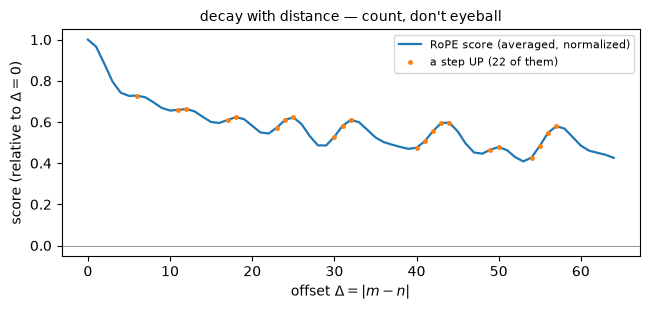

In [11]:
# E7 — auditoría de 3 partes sobre si la posición es realmente RELATIVA, comparando
# el RoPE real (importado de transformers, el mismo que usan LLaMA/Qwen/Mistral) contra
# el esquema aditivo sinusoidal de la Lección 1.

PE = sinusoidal_pe(MAX_POS, D_K)
position_probe = {}
g = torch.Generator().manual_seed(0)
q_vec, k_vec = torch.randn(D_K, generator=g), torch.randn(D_K, generator=g)

# ── (a) mismo offset Δ, en posiciones absolutas distintas ──────────────────────
# >= 6 pares (m,n), >= 3 valores de Δ distintos, y CON repeticiones (mismo Δ, distinto m,n)
pairs = [(1, 3), (2, 4), (10, 12), (1, 2), (5, 6), (0, 4), (7, 11)]
by_delta = {}
print("(a) same offset at different absolute positions — HF's real RoPE vs additive sinusoidal\n")
print(f"{'m':>4} {'n':>4} {'Δ':>4} {'RoPE (HF)':>13} {'PE(m)·PE(n)':>14}")
for (m, n_) in pairs:
    r = rope_pair_score(q_vec, k_vec, m, n_)   # score real de RoPE (HF)
    s = (PE[m] @ PE[n_]).item()                # score del esquema aditivo sinusoidal
    by_delta.setdefault(n_ - m, []).append((r, s))
    print(f"{m:4d} {n_:4d} {n_ - m:4d} {r:13.6f} {s:14.6f}")
print("\n    spread inside each Δ group (0 would be perfectly relative):")
for d_, vals in sorted(by_delta.items()):
    if len(vals) > 1:            # solo tiene sentido medir "spread" si hay >= 2 pares con el mismo Δ
        rs, ss = [v[0] for v in vals], [v[1] for v in vals]
        print(f"      Δ={d_}: RoPE {max(rs) - min(rs):.2e}    sinusoidal {max(ss) - min(ss):.2e}")
position_probe["by_delta"] = {k: v for k, v in by_delta.items()}

# ── (b) mover TODA la oración y volver a calcular los scores ───────────────────
X = torch.randn(6, D_K, generator=g)
base_r, base_a = rope_scores(X, shift=0), additive_pe_scores(X, PE, shift=0)   # referencia, sin desplazar
print(f"\n(b) move the whole sentence down the sequence and re-score")
print(f"    (for scale: a typical |score| here is {base_r.abs().mean():.2f})\n")
print(f"{'shift':>7} {'RoPE max|Δ|':>15} {'additive max|Δ|':>18}")
shift_tab = {}
for s in (5, 50, 500, 2000):
    r = (rope_scores(X, shift=s) - base_r).abs().max().item()             # cuánto cambia RoPE al desplazar
    a = (additive_pe_scores(X, PE, shift=s) - base_a).abs().max().item()  # cuánto cambia el esquema aditivo
    shift_tab[s] = (r, a)
    print(f"{s:7d} {r:15.2e} {a:18.2e}")
position_probe["shift"] = shift_tab

# ── (c) ¿el score decae con la distancia? ───────────────────────────────────────
deltas = np.arange(0, 65)
draws = torch.randn(256, D_K, generator=g)     # >= 100 vectores aleatorios para promediar el ruido
curves = [(lambda V: (V[0] @ V.T).numpy())(rope_rotate(v.expand(len(deltas), D_K),
                                                       torch.arange(len(deltas))))
          for v in draws]
rope_curve = np.mean(curves, axis=0)           # promedio sobre los 256 vectores, por cada Δ
rope_curve = rope_curve / rope_curve[0]        # normalizado para que Δ=0 sea 1.0
# cuenta los pasos donde el score SUBE en vez de bajar (no basta con mirar la curva a ojo)
n_up = int(sum(rope_curve[i + 1] > rope_curve[i] for i in range(len(rope_curve) - 1)))
position_probe["rope_curve"], position_probe["n_up"] = rope_curve.tolist(), n_up

print(f"\n(c) RoPE score vs offset, averaged over {len(draws)} random vectors (normalized at Δ=0)")
print(f"      Δ = 0..11 : {[round(float(x), 3) for x in rope_curve[:12]]}")
print(f"      mean over Δ ≤ 15 : {rope_curve[:16].mean():.3f}")
print(f"      mean over Δ ≥ 49 : {rope_curve[-16:].mean():.3f}   <- it does fall, on average")
print(f"      steps where the score RISES: {n_up} / {len(rope_curve) - 1}   <- so, not monotone")

fig, ax = plt.subplots(figsize=(6.6, 3.2))
ax.plot(deltas, rope_curve, "-", lw=1.6, label="RoPE score (averaged, normalized)")
rises = [i + 1 for i in range(len(rope_curve) - 1) if rope_curve[i + 1] > rope_curve[i]]
ax.plot(rises, rope_curve[rises], ".", ms=5, c="tab:orange", label=f"a step UP ({n_up} of them)")
ax.axhline(0, c="grey", lw=0.6)
ax.set_xlabel(r"offset $\Delta = |m - n|$"); ax.set_ylabel("score (relative to $\\Delta=0$)")
ax.set_title("decay with distance — count, don't eyeball", fontsize=10)
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Respuesta.**

**(a) Ambos esquemas pasan la prueba — y ahí está la trampa.** Todo par que comparte el mismo offset devuelve el *mismo* score: la dispersión dentro de cada grupo de $\Delta$ es de $\sim 10^{-6}$ o exactamente $0$, para **los dos** esquemas. Para el lado sinusoidal hay una razón limpia:

$$\text{PE}(m)\cdot\text{PE}(n) = \sum_i \big[\sin(m\omega_i)\sin(n\omega_i) + \cos(m\omega_i)\cos(n\omega_i)\big] = \sum_i \cos\big((n-m)\,\omega_i\big),$$

por la identidad de suma de ángulos — una función solo de $n-m$. Así que si uno se quedara en (a), concluiría que RoPE no aporta nada sobre el esquema de 2017. Cualquiera que solo pruebe esto se queda aquí.

**(b) Dónde se separan — y no es por poco.** Desplazar la oración deja la matriz de scores de RoPE prácticamente intacta, mientras que la aditiva cambia en una cantidad comparable a los propios scores (un $|$score$|$ típico aquí es $\approx 1.9$):

| shift | cambio máximo RoPE | cambio máximo aditivo |
|---|---|---|
| 5 | $\sim\!10^{-6}$ | $\approx 2.1$ |
| 50 | $\sim\!10^{-6}$ | $\approx 1.6$ |
| 500 | $\sim\!10^{-5}$ | $\approx 2.1$ |
| 2000 | $\sim\!10^{-5}$ | $\approx 3.3$ |

El residuo de RoPE es puro redondeo de float32, nada más — **incluso en shift 2000**. El error del esquema aditivo no se reduce con la distancia; se mantiene tan grande como la señal misma.

La razón es que el esquema aditivo calcula $(x_i + \text{PE}_i)\cdot(x_j + \text{PE}_j)$, que se expande a

$$\underbrace{x_i\cdot x_j}_{\text{contenido}} + \underbrace{\text{PE}_i\cdot\text{PE}_j}_{\text{solo depende de }\Delta} + \underbrace{x_i\cdot\text{PE}_j + \text{PE}_i\cdot x_j}_{\textbf{términos cruzados — NO son función de }\Delta}.$$

La parte (a) solo miró el término de en medio. Los **términos cruzados** mezclan contenido con posición *absoluta*, y son los que se mueven cuando la oración se desliza. RoPE no tiene términos cruzados en absoluto: rota $q$ y $k$, y la composición de las dos rotaciones deja solo $n-m$ en el score.

**Lo que (b) significa en la práctica:** por esto **RoPE extrapola más allá de la longitud de entrenamiento**. Dos tokens separados por 5 posiciones puntúan igual ya sea que estén en las posiciones 3 y 8 o en las posiciones 2003 y 2008 — así que a un modelo se le puede mostrar un documento más largo que cualquiera con el que entrenó y las *relaciones* que aprendió se mantienen. La PE aditiva no ofrece esa garantía: más allá del rango de entrenamiento, los vectores de posición que se suman son unos que el modelo nunca vio, y los términos cruzados inyectan esa novedad directamente en cada score.

**(c) Decae en promedio — y enfáticamente no es monótono.** Promediado sobre las tiradas aleatorias, el score normalizado cae de $1.0$ en $\Delta=0$ a un promedio de $\approx 0.74$ sobre $\Delta \le 15$ y $\approx 0.48$ sobre $\Delta \ge 49$: hay decaimiento real, el sesgo de "los tokens lejanos interactúan menos" que anunciaba la Lección 2. Pero **el score sube en aproximadamente un tercio de los pasos** (los puntos naranjas) — contar es la forma honesta de resolver esto, no mirar la curva de reojo.

Por qué: el score es una suma de cosenos en muchas frecuencias distintas $\theta_i$, que se desfasan y refasan entre sí. Los pares de alta frecuencia ya dieron varias vueltas completas para cuando $\Delta = 10$, mientras que los de baja frecuencia apenas se han movido, así que la suma oscila aunque su envolvente vaya bajando. La Sección 6 es el caso extremo de esto: con una **sola** frecuencia no hay envolvente en absoluto — el score es un coseno puro que oscila para siempre y nunca decae, por lo que ahí $\Delta=1$ puntuó *más bajo* que $\Delta=2$. El decaimiento es una propiedad de *promediar muchas frecuencias*, nunca una garantía sobre un par de tokens en particular.

Escribir "decae suavemente" significaría describir la diapositiva de la clase en vez de la propia gráfica. La frase defendible es: **decae en promedio, con oscilación pronunciada, y nunca es monótono.**